# 📊 Guía Completa de Pandas para Machine Learning

## 🎯 Introducción

**Pandas** es la librería fundamental en Python para el análisis y manipulación de datos. Es esencial para cualquier proyecto de Machine Learning, ya que nos permite trabajar con datos tabulares de forma eficiente y elegante.

## 🔧 Operaciones principales que veremos en este notebook:

### **📥 1. Carga y Exploración Básica de Datos**
- `pd.read_csv()` - Cargar datasets desde archivos CSV o URLs
- `df.to_csv()` - Guardar DataFrames en archivos CSV
- `df.shape` - Dimensiones del DataFrame (filas, columnas)
- `df.columns` - Nombres de las columnas
- `df.head()` / `df.tail()` - Primeras/últimas filas
- `df.describe()` - Estadísticas descriptivas
- `df.info()` - Información sobre tipos de datos y valores nulos

### **🎯 2. Acceso y Selección de Datos**
- `df["columna"]` - Acceso a una columna (Series)
- `df[["col1", "col2"]]` - Selección de múltiples columnas
- `df.iloc[]` - Acceso por posición (índices numéricos)
- `df.loc[]` - Acceso por etiquetas
- Slicing y selección de rangos

### **🔍 3. Filtrado de Datos**
- Filtros condicionales: `df[df["columna"] > valor]`
- Filtros múltiples con operadores lógicos
- Selección basada en condiciones complejas

### **🏗️ 4. Creación de Objetos Pandas**
- Desde listas: `pd.Series()`, `pd.DataFrame()`
- Desde diccionarios
- Desde arrays de NumPy
- Conversión entre Series y DataFrames

### **↔️ 5. Conversión de Pandas a Otros Formatos**
- `to_list()` - Convertir a listas de Python
- `to_dict()` - Convertir a diccionarios
- `to_numpy()` / `.values` - Convertir a arrays de NumPy

### **🧹 6. Limpieza y Transformación de Datos**
- `df.isna()` / `df.isnull()` - Detección de valores perdidos
- `df.dropna()` - Eliminación de valores nulos
- `df.fillna()` - Imputación de valores perdidos
- `df.drop_duplicates()` - Eliminación de duplicados
- `pd.get_dummies()` - One-hot encoding
- `df.rename()` - Renombrar columnas
- `df.drop()` - Eliminar columnas o filas
- `df.groupby()` - Agregación y agrupamiento
- Ingeniería de características (feature engineering)

### **📏 7. Escalado y Normalización de Atributos**
- Normalización Min-Max manual y con scikit-learn
- Estandarización (z-score)
- Escalado robusto (RobustScaler)
- Transformación logarítmica

### **🎲 8. Detección y Manejo de Outliers**
- Método IQR (Rango Intercuartílico)
- Visualización con boxplots
- Análisis con scatterplots

---

## 📚 Dataset de Referencia

Emplearemos datasets disponibles en abierto en el siguiente repositorio GitHub:
- 🔗 https://github.com/gakudo-ai/open-datasets

## ⚙️ Configuración Inicial

> **⚠️ IMPORTANTE:** Si ejecutas este notebook en **VS Code** (en lugar de Google Colab), descomenta las siguientes líneas para evitar errores SSL al cargar datos desde URLs HTTPS.

In [1]:
# Descomenta estas líneas si usas VS Code:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import numpy as np

# 📥 1. Carga y Exploración Básica de Datos

En esta sección aprenderemos a cargar un dataset y realizar una exploración inicial para comprender su estructura y contenido.

In [2]:
# Cargar el dataset desde URL
df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/50_Startups.csv")

print("🔹 Dimensiones del DataFrame (filas, columnas):")
display(df.shape)

print("\n🔹 Nombres de las columnas:")
display(df.columns)

print("\n🔹 Primeras 5 filas:")
display(df.head())

print("\n🔹 Estadísticas descriptivas:")
display(df.describe())

🔹 Dimensiones del DataFrame (filas, columnas):


(50, 5)


🔹 Nombres de las columnas:


Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')


🔹 Primeras 5 filas:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



🔹 Estadísticas descriptivas:


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### Acceso a Series y Guardado de Archivos

In [3]:
# Acceder a una columna como Series de Pandas
gastos_marketing = df["Marketing Spend"]
print("🔹 Primeras filas de la columna 'Marketing Spend':")
display(gastos_marketing.head())

# Guardar el DataFrame en un archivo CSV
df.to_csv("50_Startups_copia.csv", index=False)
print("\n✅ DataFrame guardado exitosamente en '50_Startups_copia.csv'")

🔹 Primeras filas de la columna 'Marketing Spend':


0    471784.10
1    443898.53
2    407934.54
3    383199.62
4    366168.42
Name: Marketing Spend, dtype: float64


✅ DataFrame guardado exitosamente en '50_Startups_copia.csv'


# 🎯 2. Acceso y Selección de Datos

Pandas ofrece múltiples formas de acceder a datos específicos dentro de un DataFrame: por columnas, filas, posición o etiquetas.

In [4]:
# Volvemos a cargar el dataset 50 Startups
df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/50_Startups.csv")

print("🔹 Acceso a una columna (Series):")
marketing = df["Marketing Spend"]
display(marketing.head())

print("\n🔹 Acceso a múltiples columnas:")
subset = df[["R&D Spend", "Marketing Spend", "Profit"]]
display(subset.head())

🔹 Acceso a una columna (Series):


0    471784.10
1    443898.53
2    407934.54
3    383199.62
4    366168.42
Name: Marketing Spend, dtype: float64


🔹 Acceso a múltiples columnas:


,R&D Spend,Marketing Spend,Profit
0,165349.20,471784.10,192261.83
1,162597.70,443898.53,191792.06
2,153441.51,407934.54,191050.39
3,144372.41,383199.62,182901.99
4,142107.34,366168.42,166187.94


### Acceso por Posición (iloc) y Etiqueta (loc)

In [5]:
# iloc: Acceso por POSICIÓN (índices numéricos)
print("🔹 Primera fila con iloc:")
display(df.iloc[0])

print("\n🔹 Primeras 5 filas:")
display(df.iloc[0:5])

print("\n🔹 Fila 0, columna 1 (por posición):")
display(df.iloc[0, 1])

# loc: Acceso por ETIQUETA (nombres de índice/columna)
print("\n🔹 Fila con etiqueta 3 usando loc:")
display(df.loc[3])

print("\n🔹 Primeras 3 filas y columnas específicas:")
display(df.loc[0:2, ["R&D Spend", "Profit"]])

# Nota: loc[0, 2] busca índices con etiquetas 0 y 2
# Para filas no consecutivas, usar iloc con lista: df.iloc[[0, 2]]

🔹 Primera fila con iloc:


R&D Spend           165349.2
Administration      136897.8
Marketing Spend     471784.1
State               New York
Profit             192261.83
Name: 0, dtype: object


🔹 Primeras 5 filas:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



🔹 Fila 0, columna 1 (por posición):


np.float64(136897.8)


🔹 Fila con etiqueta 3 usando loc:


R&D Spend          144372.41
Administration     118671.85
Marketing Spend    383199.62
State               New York
Profit             182901.99
Name: 3, dtype: object


🔹 Primeras 3 filas y columnas específicas:


,R&D Spend,Profit
0,165349.20,192261.83
1,162597.70,191792.06
2,153441.51,191050.39


# 🔍 3. Filtrado de Datos

Los filtros lógicos permiten seleccionar filas que cumplan ciertas condiciones, esencial para análisis de datos.

In [6]:
# Filtro simple: Empresas con R&D Spend mayor a 100,000
print("🔹 Empresas con alta inversión en R&D (> 100,000):")
altos_inversionistas = df[df["R&D Spend"] > 100000]
display(altos_inversionistas.head())

# Filtro categórico: Empresas en California
print("\n🔹 Empresas en California:")
display(df[df["State"] == "California"].head())

# Selección específica: Solo columna Marketing Spend como DataFrame (no Series)
marketing_df = df[["Marketing Spend"]]
print("\n🔹 Columna como DataFrame:")
display(marketing_df.head())

🔹 Empresas con alta inversión en R&D (> 100,000):


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



🔹 Empresas en California:


,R&D Spend,Administration,Marketing Spend,State,Profit
1,162597.70,151377.59,443898.53,California,191792.06
6,134615.46,147198.87,127716.82,California,156122.51
9,123334.88,108679.17,304981.62,California,149759.96
11,100671.96,91790.61,249744.55,California,144259.40
13,91992.39,135495.07,252664.93,California,134307.35



🔹 Columna como DataFrame:


,Marketing Spend
0,471784.10
1,443898.53
2,407934.54
3,383199.62
4,366168.42


# 🏗️ 4. Creación de Objetos Pandas

Pandas permite crear Series y DataFrames desde colecciones nativas de Python (listas, diccionarios) y desde arrays de NumPy.

### Desde Colecciones de Python

In [7]:
# Desde una lista → Series
print("🔹 Series desde lista:")
lista = [10, 20, 30]
serie = pd.Series(lista)
display(serie)

# Desde un diccionario de escalares → Series
print("\n🔹 Series desde diccionario:")
dic = {"a": 1, "b": 2, "c": 3}
serie = pd.Series(dic)
display(serie)

# Desde un diccionario de listas → DataFrame
print("\n🔹 DataFrame desde diccionario de listas:")
df_nuevo = pd.DataFrame({
    "Nombre": ["Ana", "Luis"],
    "Edad": [28, 35],
    "Ciudad": ["Madrid", "Sevilla"]
})
display(df_nuevo)

# Desde una lista de listas → DataFrame
print("\n🔹 DataFrame desde lista de listas:")
lista = [[1, 'Ana'], [2, 'Luis']]
df_nuevo2 = pd.DataFrame(lista, columns=['ID', 'Nombre'])
display(df_nuevo2)

# Desde una lista de diccionarios → DataFrame
print("\n🔹 DataFrame desde lista de diccionarios:")
datos = [{"Nombre": "Ana", "Edad": 28}, {"Nombre": "Luis", "Edad": 35}]
df_nuevo3 = pd.DataFrame(datos)
display(df_nuevo3)

🔹 Series desde lista:


0    10
1    20
2    30
dtype: int64


🔹 Series desde diccionario:


a    1
b    2
c    3
dtype: int64


🔹 DataFrame desde diccionario de listas:


,Nombre,Edad,Ciudad
0,Ana,28,Madrid
1,Luis,35,Sevilla



🔹 DataFrame desde lista de listas:


,ID,Nombre
0,1,Ana
1,2,Luis



🔹 DataFrame desde lista de diccionarios:


,Nombre,Edad
0,Ana,28
1,Luis,35


### Desde Arrays de NumPy

In [8]:
# Array 1D → Series
print("🔹 Series desde array 1D:")
arr = np.array([5, 10, 15])
serie = pd.Series(arr)
display(serie)

# Array 2D → DataFrame
print("\n🔹 DataFrame desde array 2D:")
arr = np.array([[1, 2], [3, 4]])
df_array = pd.DataFrame(arr, columns=["Col1", "Col2"])
display(df_array)

# Array 1D interpretado como N filas y 1 columna
print("\n🔹 DataFrame desde array 1D (N filas × 1 columna):")
arr = np.array([1, 2, 3])
df_array2 = pd.DataFrame(arr)
display(df_array2)

# Truco: Convertir array 1D en DataFrame de 1 fila × N columnas
print("\n🔹 DataFrame desde array 1D (1 fila × N columnas):")
arr = np.array([10, 20, 30])
df_array3 = pd.DataFrame(arr.reshape(1, -1), columns=['A', 'B', 'C'])
display(df_array3)

🔹 Series desde array 1D:


0     5
1    10
2    15
dtype: int64


🔹 DataFrame desde array 2D:


,Col1,Col2
0,1,2
1,3,4



🔹 DataFrame desde array 1D (N filas × 1 columna):


,0
0,1
1,2
2,3



🔹 DataFrame desde array 1D (1 fila × N columnas):


,A,B,C
0,10,20,30


# ↔️ 5. Conversión de Pandas a Otros Formatos

A menudo necesitamos convertir objetos de Pandas de vuelta a colecciones nativas de Python o arrays de NumPy para integrarlos con otras librerías.

### A Colecciones de Python

In [9]:
# Series → Lista
print("🔹 Convertir Series a lista:")
marketing = df["Marketing Spend"]
lista = marketing.tolist()
display(lista[:5])

# Series → Diccionario (los índices serán las claves)
print("\n🔹 Convertir Series a diccionario:")
serie_ejemplo = pd.Series({"a": 1, "b": 2, "c": 3})
dic = serie_ejemplo.to_dict()
display(dic)

# DataFrame → Lista de diccionarios
print("\n🔹 DataFrame a lista de diccionarios (cada fila = un diccionario):")
lista_dicts = df[:3].to_dict(orient="records")
display(lista_dicts)

# DataFrame → Lista de listas
print("\n🔹 DataFrame a lista de listas:")
lista_listas = df[:3].values.tolist()
display(lista_listas)

🔹 Convertir Series a lista:


[471784.1, 443898.53, 407934.54, 383199.62, 366168.42]


🔹 Convertir Series a diccionario:


{'a': 1, 'b': 2, 'c': 3}


🔹 DataFrame a lista de diccionarios (cada fila = un diccionario):


[{'R&D Spend': 165349.2,
  'Administration': 136897.8,
  'Marketing Spend': 471784.1,
  'State': 'New York',
  'Profit': 192261.83},
 {'R&D Spend': 162597.7,
  'Administration': 151377.59,
  'Marketing Spend': 443898.53,
  'State': 'California',
  'Profit': 191792.06},
 {'R&D Spend': 153441.51,
  'Administration': 101145.55,
  'Marketing Spend': 407934.54,
  'State': 'Florida',
  'Profit': 191050.39}]


🔹 DataFrame a lista de listas:


[[165349.2, 136897.8, 471784.1, 'New York', 192261.83],
 [162597.7, 151377.59, 443898.53, 'California', 191792.06],
 [153441.51, 101145.55, 407934.54, 'Florida', 191050.39]]

### A Arrays de NumPy

In [10]:
# Series → Array 1D
print("🔹 Convertir Series a array NumPy:")
array_marketing = marketing.to_numpy()
display(array_marketing[:5])

# DataFrame → Array 2D
print("\n🔹 Convertir DataFrame a array NumPy con to_numpy():")
arr = df.to_numpy()
print(f"Shape: {arr.shape}, dtype: {arr.dtype}")
display(arr[:3])

# Alternativa: df.values (más antiguo, menos recomendado)
print("\n🔹 Alternativa con .values:")
arr_values = df.values
print(f"dtype con .values: {arr_values.dtype}")

print("\n⚠️ Nota: to_numpy() es más confiable que .values para datasets con tipos mixtos.")

🔹 Convertir Series a array NumPy:


array([471784.1 , 443898.53, 407934.54, 383199.62, 366168.42])


🔹 Convertir DataFrame a array NumPy con to_numpy():
Shape: (50, 5), dtype: object


array([[165349.2, 136897.8, 471784.1, 'New York', 192261.83],
       [162597.7, 151377.59, 443898.53, 'California', 191792.06],
       [153441.51, 101145.55, 407934.54, 'Florida', 191050.39]],
      dtype=object)


🔹 Alternativa con .values:
dtype con .values: object

⚠️ Nota: to_numpy() es más confiable que .values para datasets con tipos mixtos.


# 🧹 6. Limpieza y Transformación de Datos

La preparación de datos es crucial para el éxito de cualquier modelo de Machine Learning. Usaremos el dataset de viviendas de California para ilustrar estos procesos.

In [11]:
# Cargar dataset de viviendas de California
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/housing.csv"
housing_df = pd.read_csv(url)

print("🔹 Primeras filas del dataset:")
display(housing_df.head())

print("\n🔹 Información del dataset:")
housing_df.info()

print("\n🔹 Estadísticas descriptivas:")
display(housing_df.describe())

🔹 Primeras filas del dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



🔹 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

🔹 Estadísticas descriptivas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Análisis de Valores Categóricos y Nulos

In [12]:
# Conteo de valores únicos en atributo categórico
print("🔹 Distribución de 'ocean_proximity':")
display(housing_df["ocean_proximity"].value_counts())

# Detección de valores perdidos
print("\n🔹 Valores nulos por columna:")
display(housing_df.isna().sum())

🔹 Distribución de 'ocean_proximity':


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


🔹 Valores nulos por columna:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Manejo de Valores Perdidos y Duplicados

In [13]:
# Opción 1: Eliminar filas con valores faltantes
print("🔹 Eliminar filas con NaN en 'total_bedrooms':")
housing_df_dropna = housing_df.dropna(subset=["total_bedrooms"])
print(f"Shape después de dropna: {housing_df_dropna.shape}")

# Opción 2: Imputar con la mediana (más común en ML)
print("\n🔹 Imputar valores faltantes con la mediana:")
mediana = housing_df["total_bedrooms"].median()
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(mediana)
print(f"Shape después de fillna: {housing_df.shape}")
print(f"Valores nulos restantes: {housing_df['total_bedrooms'].isna().sum()}")

# Eliminación de duplicados
print("\n🔹 Eliminar duplicados:")
housing_df.drop_duplicates(inplace=True)
print(f"Shape final: {housing_df.shape}")

🔹 Eliminar filas con NaN en 'total_bedrooms':
Shape después de dropna: (20433, 10)

🔹 Imputar valores faltantes con la mediana:
Shape después de fillna: (20640, 10)
Valores nulos restantes: 0

🔹 Eliminar duplicados:
Shape final: (20640, 10)


### One-Hot Encoding

Conversión de atributos categóricos en atributos numéricos binarios mediante `pd.get_dummies()`. Crea una columna nueva por cada categoría posible.

In [14]:
# Aplicar one-hot encoding a la columna categórica
print("🔹 Aplicando one-hot encoding a 'ocean_proximity':")
df_dummies = pd.get_dummies(housing_df, columns=["ocean_proximity"])
print(f"Columnas originales: {len(housing_df.columns)}")
print(f"Columnas después de one-hot: {len(df_dummies.columns)}")
display(df_dummies.head())

🔹 Aplicando one-hot encoding a 'ocean_proximity':
Columnas originales: 10
Columnas después de one-hot: 14


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


### Ingeniería de Características

Creación de nuevas columnas calculadas a partir de las existentes, renombrado y eliminación de columnas.

In [15]:
# Crear nuevas columnas calculadas
print("🔹 Creando columnas derivadas:")
housing_df["rooms_per_household"] = housing_df["total_rooms"] / housing_df["households"]
housing_df["population_per_household"] = housing_df["population"] / housing_df["households"]

# Renombrar columnas
housing_df.rename(columns={"housing_median_age": "median_age"}, inplace=True)

# Eliminar columnas innecesarias
housing_df.drop(columns=["longitude", "latitude"], inplace=True)

print("Nuevas columnas creadas y dataset limpio:")
display(housing_df.head())

# Agrupar y agregar datos
print("\n🔹 Promedio de ingresos por categoría de proximidad al océano:")
display(housing_df.groupby("ocean_proximity").mean()[["median_income", "median_house_value"]])

🔹 Creando columnas derivadas:
Nuevas columnas creadas y dataset limpio:


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467



🔹 Promedio de ingresos por categoría de proximidad al océano:


,median_income,median_house_value
ocean_proximity,,
<1H OCEAN,4.230682,240084.285464
INLAND,3.208996,124805.392001
ISLAND,2.744420,380440.000000
NEAR BAY,4.172885,259212.311790
NEAR OCEAN,4.005785,249433.977427


# 📏 7. Escalado y Normalización de Atributos

El escalado es fundamental en ML para que todos los atributos contribuyan equitativamente al modelo. Veremos métodos manuales con Pandas y métodos con scikit-learn.

In [16]:
# Preparar datos: seleccionar solo atributos numéricos
atributos_numericos = housing_df.select_dtypes(include=['float64', 'int64']).columns
housing_df_num = housing_df[atributos_numericos]
print(f"🔹 Atributos numéricos seleccionados: {len(atributos_numericos)}")

🔹 Atributos numéricos seleccionados: 9


### Escalado Manual con Pandas

In [17]:
# Normalización Min-Max: (x - min) / (max - min)
print("🔹 Normalización Min-Max manual:")
df_manual_minmax = (housing_df_num - housing_df_num.min()) / (housing_df_num.max() - housing_df_num.min())
display(df_manual_minmax.head())

# Estandarización z-score: (x - mean) / std
print("\n🔹 Estandarización (z-score) manual:")
df_standardized = (housing_df_num - housing_df_num.mean()) / housing_df_num.std()
display(df_standardized.head())

🔹 Normalización Min-Max manual:


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,0.043512,0.001499
1,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,0.038224,0.001141
2,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,0.052756,0.001698
3,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,0.035241,0.001493
4,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,0.038534,0.001198



🔹 Estandarización (z-score) manual:


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,0.982119,-0.804800,-0.972453,-0.974405,-0.977009,2.344709,2.129580,0.628544,-0.049595
1,-0.607004,2.045841,1.357111,0.861418,1.669921,2.332181,1.314124,0.327033,-0.092510
2,1.856137,-0.535733,-0.827004,-0.820757,-0.843616,1.782656,1.258663,1.155592,-0.025842
3,1.856137,-0.624199,-0.719706,-0.766010,-0.733764,0.932945,1.165072,0.156962,-0.050328
4,1.856137,-0.462393,-0.612408,-0.759828,-0.629142,-0.012881,1.172871,0.344702,-0.085614


### Escalado con scikit-learn

Aunque Pandas permite escalado manual, **scikit-learn** ofrece funciones probadas y eficientes, recomendadas para uso en producción.

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. Estandarización (z-score) con StandardScaler
print("🔹 StandardScaler (z-score):")
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(housing_df_num), columns=atributos_numericos)
display(df_standardized.head())

# 2. Normalización Min-Max con MinMaxScaler
print("\n🔹 MinMaxScaler (normalización 0-1):")
scaler = MinMaxScaler()
df_minmax = pd.DataFrame(scaler.fit_transform(housing_df_num), columns=atributos_numericos)
display(df_minmax.head())

# 3. Escalado robusto (usa mediana y rango intercuartílico, resistente a outliers)
print("\n🔹 RobustScaler (resistente a outliers):")
scaler = RobustScaler()
df_robust = pd.DataFrame(scaler.fit_transform(housing_df_num), columns=atributos_numericos)
display(df_robust.head())

# 4. Transformación logarítmica (útil para distribuciones asimétricas)
print("\n🔹 Transformación logarítmica:")
df_log = np.log1p(housing_df_num)  # log1p = log(1+x) para evitar log(0)
display(df_log.head())

🔹 StandardScaler (z-score):


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,0.628559,-0.049597
1,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,0.327041,-0.092512
2,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,1.155620,-0.025843
3,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,0.156966,-0.050329
4,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,0.344711,-0.085616



🔹 MinMaxScaler (normalización 0-1):


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,0.043512,0.001499
1,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,0.038224,0.001141
2,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,0.052756,0.001698
3,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,0.035241,0.001493
4,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,0.038534,0.001198



🔹 RobustScaler (resistente a outliers):


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,0.631579,-0.733422,-0.883755,-0.899787,-0.870769,2.197582,1.880448,1.088935,-0.307981
1,-0.421053,2.924276,1.937906,1.316631,2.243077,2.186664,1.232041,0.626066,-0.830800
2,1.210526,-0.388178,-0.707581,-0.714286,-0.713846,1.707732,1.187941,1.898042,-0.018599
3,1.210526,-0.501691,-0.577617,-0.648188,-0.584615,0.967177,1.113523,0.364978,-0.316908
4,1.210526,-0.294074,-0.447653,-0.640725,-0.461538,0.142854,1.119724,0.653191,-0.746784



🔹 Transformación logarítmica:


,median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household
0,3.737670,6.781058,4.867534,5.777652,4.844187,2.232720,13.022766,2.077455,1.268511
1,3.091042,8.867850,7.009409,7.784057,7.037906,2.230165,12.789687,1.979364,1.134572
2,3.970292,7.291656,5.252273,6.208590,5.181784,2.111110,12.771673,2.228738,1.335596
3,3.970292,7.150701,5.463832,6.326149,5.393628,1.893579,12.740520,1.919471,1.266369
4,3.970292,7.395108,5.638355,6.338594,5.560682,1.578195,12.743154,1.985385,1.157342


# 🎲 8. Detección y Manejo de Outliers

Los outliers pueden afectar significativamente el rendimiento de modelos de ML. Veremos métodos estadísticos y visuales para detectarlos y eliminarlos.

In [19]:
# Cargar dataset de startups para análisis de outliers
url = 'https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/50_Startups.csv'
df_startups = pd.read_csv(url)
print("🔹 Dataset de Startups cargado:")
display(df_startups.head())

🔹 Dataset de Startups cargado:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


### Método IQR (Rango Intercuartílico) con Boxplot

🔹 Boxplot de 'Profit' para detectar outliers:


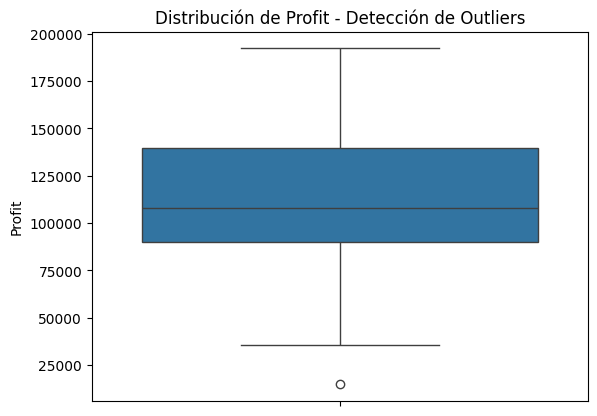


🔹 Límites IQR:
Límite inferior: 15698.29
Límite superior: 214206.59

✅ Shape original: (50, 5)
✅ Shape sin outliers: (49, 5)
🗑️ Outliers eliminados: 1


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar outliers con boxplot
print("🔹 Boxplot de 'Profit' para detectar outliers:")
sns.boxplot(y=df_startups['Profit'])
plt.title('Distribución de Profit - Detección de Outliers')
plt.show()

# Calcular límites IQR
Q1 = df_startups['Profit'].quantile(0.25)
Q3 = df_startups['Profit'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"\n🔹 Límites IQR:")
print(f"Límite inferior: {lower_limit:.2f}")
print(f"Límite superior: {upper_limit:.2f}")

# Filtrar datos sin outliers
df_filtered = df_startups[(df_startups['Profit'] >= lower_limit) & (df_startups['Profit'] <= upper_limit)]
print(f"\n✅ Shape original: {df_startups.shape}")
print(f"✅ Shape sin outliers: {df_filtered.shape}")
print(f"🗑️ Outliers eliminados: {df_startups.shape[0] - df_filtered.shape[0]}")

### Método Alternativo: Detección Visual con Scatterplot

🔹 Scatterplot para identificar outliers:


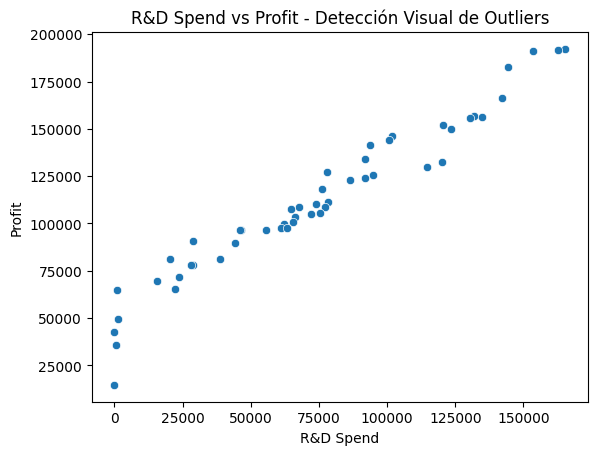


🔹 Filtrando outliers con umbrales visuales:
Shape después de filtrar: (45, 5)

🔹 Scatterplot después de eliminar outliers:


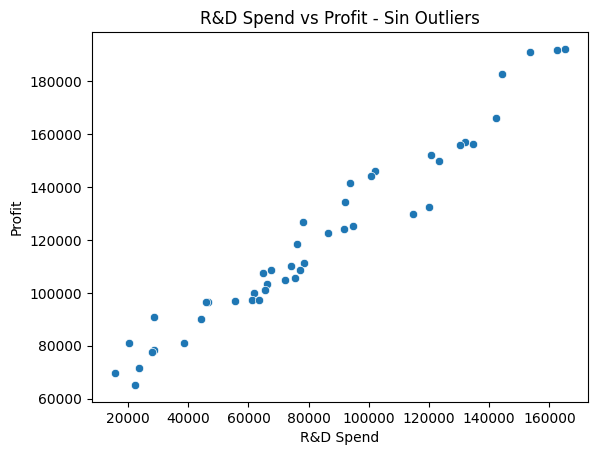

In [21]:
# Scatterplot para detectar outliers visualmente
print("🔹 Scatterplot para identificar outliers:")
sns.scatterplot(data=df_startups, x='R&D Spend', y='Profit')
plt.title('R&D Spend vs Profit - Detección Visual de Outliers')
plt.show()

# Filtrar outliers basándose en observación visual
# Establecemos umbrales razonables
print("\n🔹 Filtrando outliers con umbrales visuales:")
df_filtered_visual = df_startups[(df_startups['R&D Spend'] > 5000) & (df_startups['Profit'] > 25000)]
print(f"Shape después de filtrar: {df_filtered_visual.shape}")

# Visualizar resultado
print("\n🔹 Scatterplot después de eliminar outliers:")
sns.scatterplot(data=df_filtered_visual, x='R&D Spend', y='Profit')
plt.title('R&D Spend vs Profit - Sin Outliers')
plt.show()

# 🎓 Conclusiones

¡Felicidades! Has completado esta guía completa de **Pandas para Machine Learning**.

## 📚 Resumen de lo aprendido:

✅ **Carga y exploración** de datos desde múltiples fuentes  
✅ **Acceso y selección** eficiente con iloc, loc y filtros  
✅ **Creación y conversión** entre estructuras de datos  
✅ **Limpieza de datos**: manejo de nulos, duplicados y transformaciones  
✅ **Ingeniería de características**: creación de nuevas variables  
✅ **Escalado y normalización** con múltiples métodos  
✅ **Detección de outliers** con métodos estadísticos y visuales  

## 🚀 Próximos pasos:

- Practicar con tus propios datasets
- Combinar Pandas con scikit-learn para construir modelos completos
- Explorar visualizaciones avanzadas con Matplotlib y Seaborn
- Aprender sobre análisis de series temporales con Pandas

---

**📖 Recursos adicionales:**
- [Documentación oficial de Pandas](https://pandas.pydata.org/docs/)
- [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- [scikit-learn Documentation](https://scikit-learn.org/)